In [1]:
import numpy as np

# Random seed
random_seed = 1354
np.random.seed(random_seed)

# GP configuration
n_bases = 4
n_order = 2
num_points_train = 36
num_points_test = 5000
lower_bounds = [-5] * n_bases
upper_bounds = [5] * n_bases
n_clusters = 3
kernel = "SE"
kernel_type = "isotropic"
normalize = True
n_restart_optimizer = 15
swarm_size = 250

In [2]:
import pyoti.sparse as oti

def styblinski_tang_function(X, alg=oti):
    x1, x2, x3, x4 = X[:,0], X[:,1], X[:,2], X[:,3]
    return 0.5 * (x1**4 - 16*x1**2 + 5*x1 +
                  x2**4 - 16*x2**2 + 5*x2 +
                  x3**4 - 16*x3**2 + 5*x3 +
                  x4**4 - 16*x4**2 + 5*x4)

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [3]:
from scipy.stats import qmc
import utils

def generate_sobol_points(num_points):
    sampler = qmc.Sobol(d=n_bases, scramble=True)
    samples = sampler.random_base2(m=int(np.ceil(np.log2(num_points))))
    quasi_samples = samples[:num_points]
    return utils.scale_samples(quasi_samples, lower_bounds, upper_bounds)

X_train_initial = generate_sobol_points(num_points_train)
print("Training points shape:", X_train_initial.shape)

Training points shape: (36, 4)


In [4]:
from sklearn.cluster import KMeans
import itertools

def cluster_and_reorder(X_train, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_seed, n_init='auto')
    labels = kmeans.fit_predict(X_train)

    unsorted_groups = [[] for _ in range(n_clusters)]
    for i, label in enumerate(labels):
        unsorted_groups[label].append(i)

    reorder_map = list(itertools.chain.from_iterable(unsorted_groups))
    X_train_reordered = X_train[reorder_map]

    sequential_indices = []
    current_pos = 0
    for group in unsorted_groups:
        sequential_indices.append(list(range(current_pos, current_pos + len(group))))
        current_pos += len(group)

    return X_train_reordered, sequential_indices

X_train_reordered, sequential_indices = cluster_and_reorder(X_train_initial, n_clusters)
print("Reordered training points shape:", X_train_reordered.shape)

Reordered training points shape: (36, 4)


In [5]:
import pyoti.sparse as oti
import utils

def prepare_submodel_data(X_train, submodel_indices):
    main_derivatives = [
        [[[i+1, order+1]] for i in range(n_bases)] for order in range(n_order)
    ]
    derivative_specs = [main_derivatives for _ in submodel_indices]

    y_function_values = styblinski_tang_function(X_train, alg=np)
    submodel_data = []

    for k, indices in enumerate(submodel_indices):
        X_sub_oti = oti.array(X_train[indices])
        for i in range(n_bases):
            for j in range(X_sub_oti.shape[0]):
                X_sub_oti[j,i] += oti.e(i+1, order=n_order)

        y_with_derivatives = oti.array([styblinski_tang_function(x, alg=oti) for x in X_sub_oti])
        current_data = [y_function_values]
        for i in range(len(main_derivatives)):
            for j in range(len(main_derivatives[i])):
                deriv = y_with_derivatives.get_deriv(main_derivatives[i][j]).reshape(-1,1)
                current_data.append(deriv)
        submodel_data.append(current_data)

    return submodel_data, derivative_specs

submodel_data, derivative_specs = prepare_submodel_data(X_train_reordered, sequential_indices)
print("Number of submodels:", len(submodel_data))

Number of submodels: 3


In [6]:
from wdegp.wdegp import wdegp

gp_model = wdegp(
    X_train_reordered, submodel_data, n_order, n_bases,
    sequential_indices, derivative_specs, normalize=normalize,
    kernel=kernel, kernel_type=kernel_type
)

params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = None,
    debug = True
    )
print("GP model built and optimized.")

Gen 1: best f=571.4019621875942


Gen 2: best f=571.4019621875942


Gen 3: best f=571.4019621875942


Gen 4: best f=571.4019621875942


Gen 5: best f=571.4019621875942


...

Gen 11: best f=502.3793582794559


Gen 12: best f=502.3793582794559


Gen 13: best f=502.3793582794559


Gen 14: best f=502.3793582794559


Gen 15: best f=502.3793582794559
GP model built and optimized.


/tmp/ipykernel_218952/2956068287.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


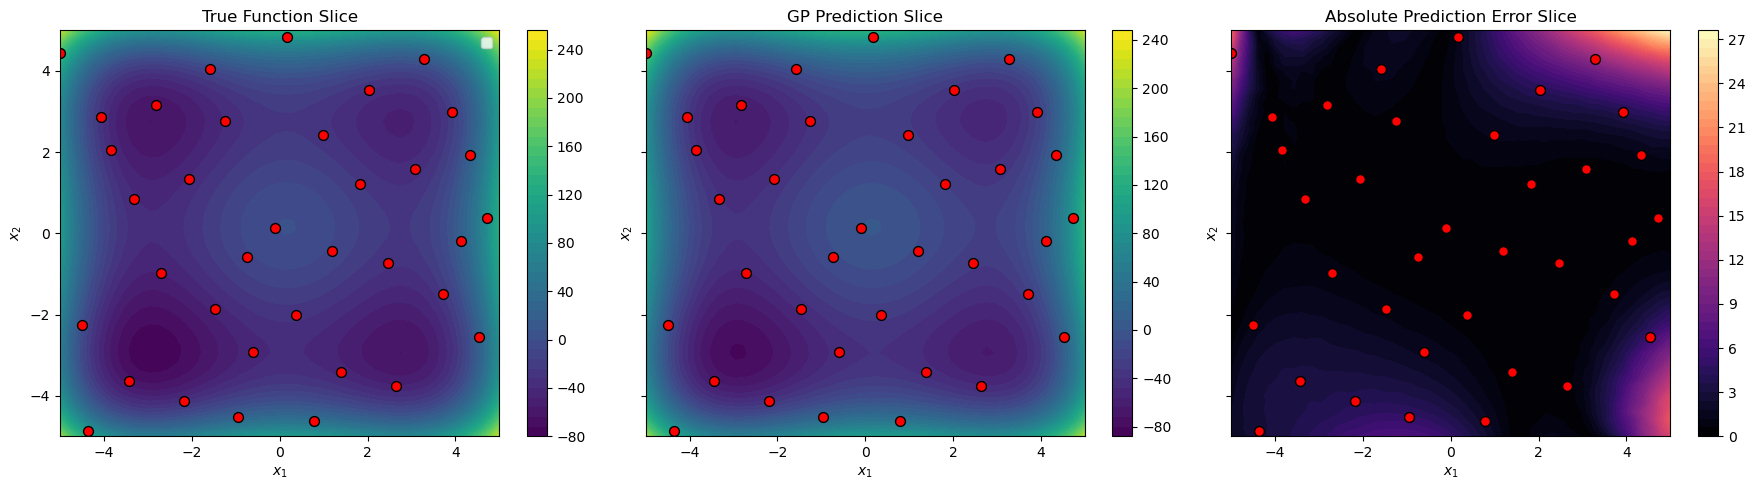

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Evaluate on 2D slice (x3=0, x4=0)
grid_points = 50
x1x2_lin = np.linspace(lower_bounds[0], upper_bounds[0], grid_points)
X1_grid, X2_grid = np.meshgrid(x1x2_lin, x1x2_lin)
X_slice = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
X_slice = np.hstack([X_slice, np.zeros((X_slice.shape[0],2))])

y_slice_pred = gp_model.predict(X_slice, params, calc_cov=False, return_submodels=False)
y_slice_true = styblinski_tang_function(X_slice, alg=np)

# Contour plots
fig, axes = plt.subplots(1,3,figsize=(18,5),sharex=True,sharey=True)

# Scatter plot of training points projection
X_train_proj = X_train_reordered[:,:2]

c1 = axes[0].contourf(X1_grid, X2_grid, y_slice_true.reshape(X1_grid.shape), levels=50, cmap="viridis")
fig.colorbar(c1, ax=axes[0])
axes[0].set_title("True Function Slice")
axes[0].scatter(X_train_proj[:,0], X_train_proj[:,1], c="red", edgecolor="k", s=50)

c2 = axes[1].contourf(X1_grid, X2_grid, y_slice_pred.reshape(X1_grid.shape), levels=50, cmap="viridis")
fig.colorbar(c2, ax=axes[1])
axes[1].set_title("GP Prediction Slice")
axes[1].scatter(X_train_proj[:,0], X_train_proj[:,1], c="red", edgecolor="k", s=50)

error_grid = np.abs(y_slice_true - y_slice_pred)
c3 = axes[2].contourf(X1_grid, X2_grid, error_grid.reshape(X1_grid.shape), levels=50, cmap="magma")
fig.colorbar(c3, ax=axes[2])
axes[2].set_title("Absolute Prediction Error Slice")
axes[2].scatter(X_train_proj[:,0], X_train_proj[:,1], c="red", edgecolor="k", s=50)

for ax in axes:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
axes[0].legend()
plt.tight_layout()
plt.show()